# **COVID-19 CT-Scan Image Classification [Math 443]**
#### *Zayn Khan, Nitin Sharan, Hanchuan Xu, Radchanon (Dew) Leelasukseree, Shangze Shi*

## [SARS-COV-2 Ct-Scan Dataset](https://www.kaggle.com/datasets/plameneduardo/sarscov2-ctscan-dataset/data)

>In this project, we train a binary classifier on CT-scan images (from the Kaggle dataset linked above) from **COVID** or **non-COVID** patients, with ~1200 images in each class (so ~2400 images total). We train a neural network on images re-constructed and tensorized from the original image dataset using Principal Component Analysis. 

### Model Architecture
> Although we may refer to this as a "logistic regression" task, we use a slightly deeper neural network with one hidden layer and dropout for regularization, which is used to prevent over-fitting. We have the following model definition:
- An input layer that accepts PCA-reconstructed features (flattened vector of reduced-dimension CT scan data)
- A hidden layer with 128 units and ReLU activation
- Dropout for regularization
- A final linear layer outputting logits for two classes (COVID vs. non-COVID)

> This structure is implemented as:

```python
self.model = nn.Sequential(
    nn.Linear(input_dim, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, num_classes)
)
```

> For our loss function, we use`CrossEntropyLoss` function, and the `Adam` optimizer to update the weights, readily tracking metrics such as accuracy and loss on both the training and validation set for each epoch (see: `model_stats.csv`)

> Our model pipeline is defined using two python modules, which also contain main programs to perform their respective functionalities in a self-contained manner:
- `pca.py`: Re-constructs the datset using `Principal Component Analysis (PCA)`
- `log_reg.py`: Trains the `Neural Network` on the projected/re-constructed dataset

> Notably, we used the `sklearn` and `PyTorch` to perform the decomposition, train the model, and output post-training metrics
> Observe that we are not using the canonical `Convolutional Neural Network` to train this model, because `Pytorch` flattens and saves the re-constructed images each into single vectors/tensors (using the `.pt` extension) instead of a common image format. From there, a `Logistic Regression-Inspired` model suffices for classifying based on the two labels.
- **In this notebook**, we will briefly explore the original, re-constructed dataset, and evaluate our model. Note that we trained this by running the main programs in `pca.py` and `log_reg.py`. The re-constructed data and model are pre-saved in this directory, but you can feel free to run these programs with custom arguments to re-perform these functions. Keep in mind that re-running this file requires some dependencies to exist in the current director **AFTER** having run both these programs.

In [1]:
# model imports, including our custom python module and some other packages for displaying metrics
import random
import os

import torch
from pca import *
from log_reg import *

from IPython.display import Image
import pandas as pd


## **Original Images**

#### *COVID Patient, Image 1, 66 KB*

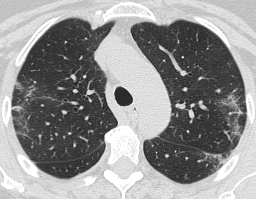

In [2]:
Image(filename='data/images/Covid/Covid (1).png') 

#### *Non-COVID Patient, Image 12, 139 KB*

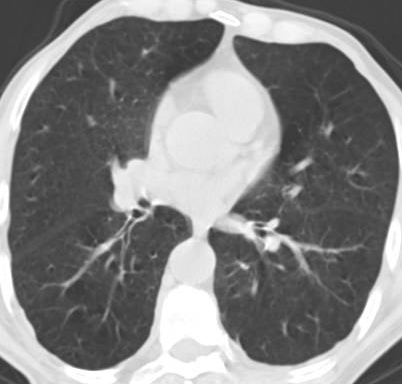

In [3]:
Image(filename='data/images/non-Covid/Non-Covid (12).png') 

## **Re-constructed Data Using PCA**
> We output some of the re-constructed image data here. For a large dataset with high-resolution, memory intense data, it would be useful to reduce the complexity of the dataset using Principal Component Analysis in order to capture as much information that is pertinent to our training, while reducing the computational implications of training on the original data. For the purposes of training, we selected the **Top-50 Principal Components** to re-construct the data with, but this value is modular
>
> Since the PCA'd data was tensorized by `PyTorch`, we had to re-format and save the entire re-constructed dataset for viewing purposes (the model itself is trained on the tensorized format located in `data/PCA_images`

#### *COVID Patient, Image 1, 33 KB **(RE-CONSTRUCTED)***

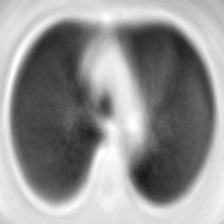

In [4]:
Image(filename='data/Reconstructed_Images/COVID/Covid (1).png') 

#### *Non-COVID Patient, Image 12, 37 KB **(RE-CONSTRUCTED)***

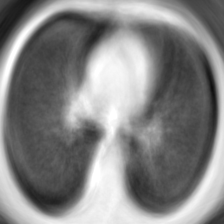

In [5]:
Image(filename='data/Reconstructed_Images/non-Covid/Non-Covid (12).png') 

## **Model Evaluation**
#### Here is the training and validation model accuracy/loss on the final model after the 100th epoch of training:

In [6]:
metrics = pd.read_csv("model_stats.csv")
metrics.loc[[99]]

,epoch,train_acc,train_loss,val_acc,val_loss
99,100,92.641129,0.182697,89.134809,0.292415


### We have reached around 89% accuracy on the validation (non-training) set, which is quite impressive for a dataset this small!

## ***Confusion Matrix***

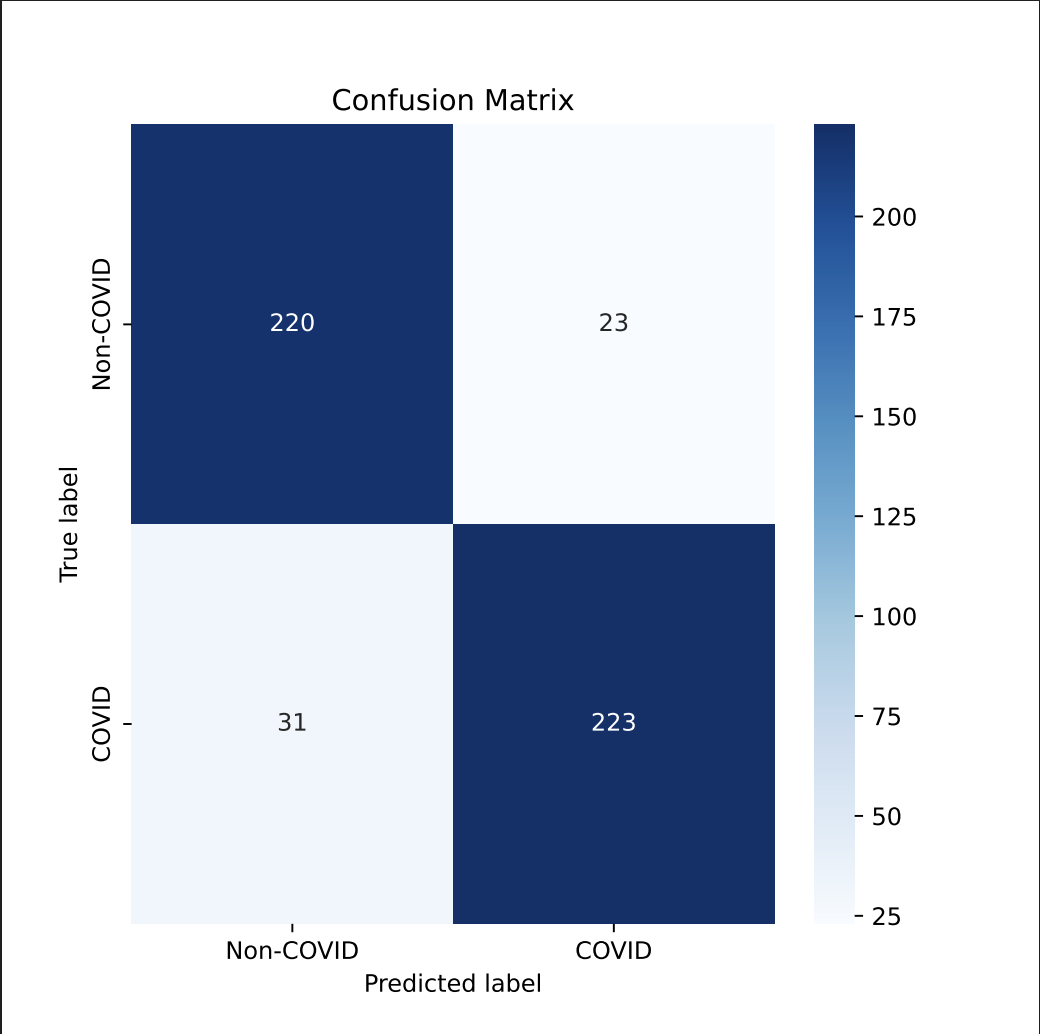

In [7]:
Image(filename='confusion_matrix.png', width=800) 

### From this confusion matrix, we have the following true positive/negative rate respectively:

In [8]:
print(f'True Positive Rate: {223/(223+31) * 100}%')

True Positive Rate: 87.79527559055119%


In [9]:
print(f'True Negative Rate: {220/(220+23) * 100}%')

True Negative Rate: 90.53497942386831%


## ***Example Prediction***
### Here, we pick a random sample from the dataset and perform a prediction on it using our final model:
> **NOTE**: We need to convert the data to the same input format that the model takes, so we  project it using our PCA model, and predict on that! Here, we can just grab the re-constructed image, since we took care of pre-processing all the original data into their re-constructed counterparts ahead of time

In [10]:
# samples in positive class 1252, # samples in negative class 1230

# helper method to perform a prediction on a random sample from the dataset in the specified class 
def predict(label):
    # load final trained model 
    input_dim = 50 # choose same input parameter based on number of PCs we used
    model = SimpleClassifier(input_dim=input_dim, num_classes=2)
    model.load_state_dict(torch.load("checkpoints/simpleclassifier_epoch100.pth"))
    model.eval()
    
    # select random image from specified input class to predict on
    if label == "positive":
        index = random.randint(1, 1252)
        pt_path = f'data/PCA_images/COVID/Covid ({index}).pt' 
    else: 
        index = random.randint(1, 1230)
        pt_path = f'data/PCA_images/non-COVID/Non-covid ({index}).pt' 

        
    
    # load the PCA-reduced tensor 
    x = torch.load(pt_path).unsqueeze(0)  # shape: [1, input_dim]
    
    # make prediction
    with torch.no_grad():
        output = model(x)
        pred_class = torch.argmax(output, dim=1).item()

    # output predicted class
    print(f"Predicting on Image ({index}):\n\tTRUE LABEL={pt_path.split('/')[-2]}\n\tPREDICTION={'COVID' if pred_class == 1 else 'non-COVID'}")


predict("positive")
predict("negative")

Predicting on Image (106):
	TRUE LABEL=COVID
	PREDICTION=COVID
Predicting on Image (752):
	TRUE LABEL=non-COVID
	PREDICTION=non-COVID
